In [ ]:
!pip install qiskit brian2 qiskit-aer pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00


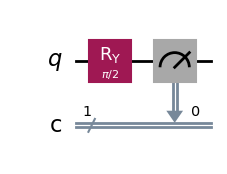

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit_layout, circuit_drawer
import matplotlib.pyplot as plt
import numpy as np

# Input variable (e.g. x = 0.5)
x = 0.5

# Build a 1-qubit, 1 classical-bit quantum circuit
qc = QuantumCircuit(1, 1)
qc.ry(x * np.pi, 0)
qc.measure(0, 0)

# Draw the circuit (matplotlib)
# This line requires a kernel restart after installing pylatexenc
qc.draw(output='mpl')

In [ ]:
from brian2 import *
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# generate synthetic data
x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, size=x.shape)

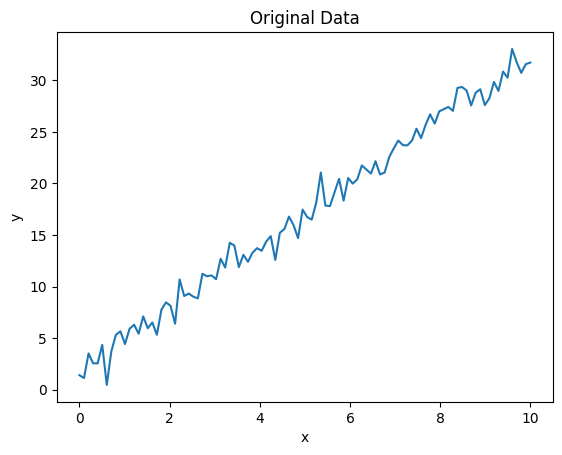

In [ ]:
import matplotlib.pyplot as plt

x_data = x
y_data = y
plt.plot(x_data, y_data)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Data')
plt.show()

In [ ]:
"""
Simple Neuron Operator for Brain Organoids Intelligence implements
"""
def simple_neuron_operator(x):
    start_scope()  # Brian2: safe repeated simulations
    defaultclock.dt = 1*ms
    eqs = '''
    dv/dt = (-v + I) / (10*ms) : 1
    I : 1
    '''
    G = NeuronGroup(1, eqs, method='euler')

    G.I = x
    G.v = 0.0

    mon = StateMonitor(G, 'v', record=True)

    run(10*ms)

    return mon.v[0][-1]

In [ ]:
"""
Simple Quantum Computing
"""
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler as AerSampler
import numpy as np

def float_to_qubit_prob(x: float, shots: int = 1000) -> float:
	"""
	Encode a float value as a Y-rotation on a single qubit, simulate, and return the probability of measuring |1>.
	Args:
		x (float): Input value to encode (scaled by pi)
		shots (int): Number of shots for the simulation
	Returns:
		float: Probability of measuring qubit in state |1>
	"""
	sampler = AerSampler()
	qc = QuantumCircuit(1, 1)
	qc.ry(x * np.pi, 0)
	qc.measure(0, 0)
	job = sampler.run(qc, shots=shots)
	result = job.result()
	quasi_dist = result.quasi_dists[0]
	prob_1 = quasi_dist.get(1, 0.0)
	return prob_1

### Model comparison experiment

Order: **(1) Classical regression (baseline)** → **(2) Regression + quantum noise** (feature from `float_to_qubit_prob`: RY encoding + **shot noise** on the simulator) → **(3) Regression + bio-inspired only** (`simple_neuron_operator`) → **(4) Bio–quantum hybrid** (quantum + bio features, as in the original model).

All models are fit with **least squares** on features consistent with the reference code.

MSE by model:
  Classical (baseline): 0.9981
  Classical + quantum noise (q feature): 80.4897
  Classical + bio-inspired only: 0.9981
  Bio–quantum hybrid: 0.9980


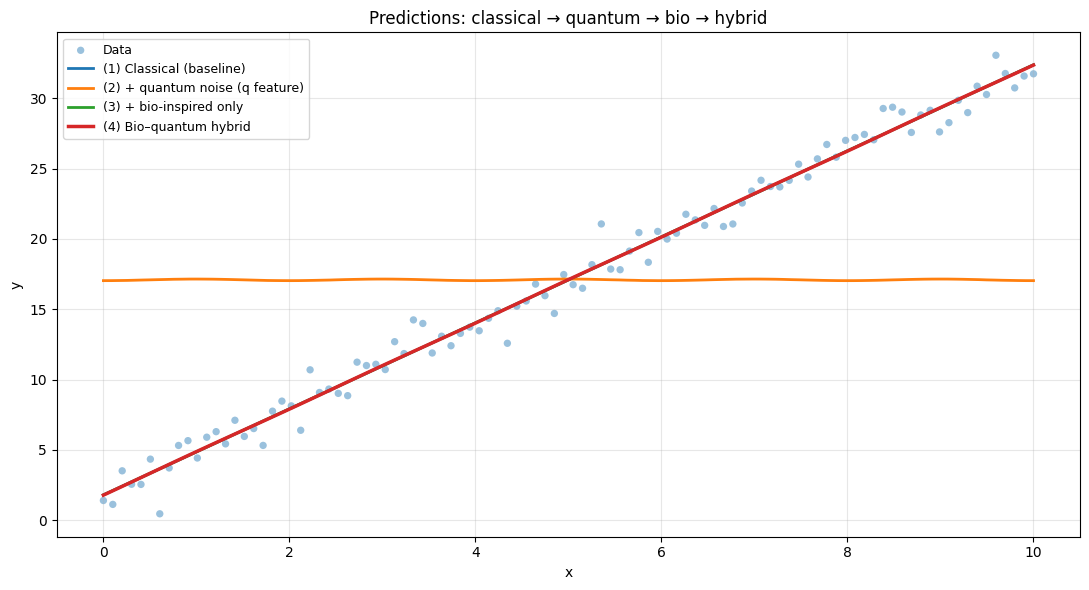

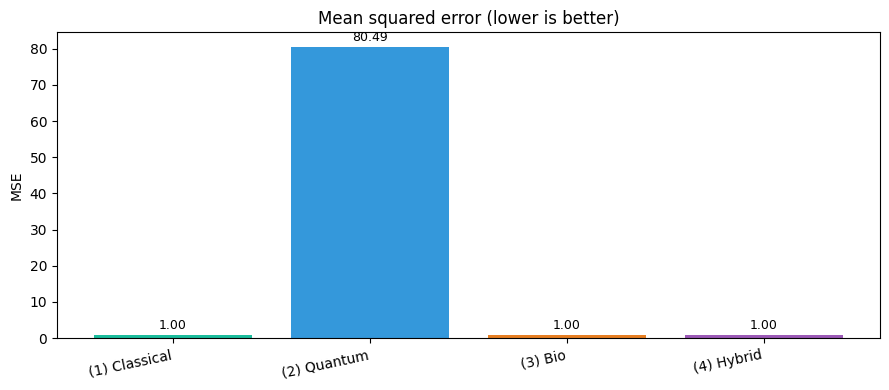

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

n = len(x_data)

# --- (1) Baseline: classical linear regression y ~ b0 + b1 * x
X_classical = np.column_stack([np.ones(n), x_data])
beta_classical, *_ = np.linalg.lstsq(X_classical, y_data, rcond=None)
y_pred_classical = X_classical @ beta_classical

# --- (2) Quantum feature: P(|1>) from the circuit (shot noise from Aer, same as reference)
q_feat = np.array([float_to_qubit_prob(float(xv)) for xv in x_data])
X_quantum = np.column_stack([np.ones(n), q_feat])
beta_quantum, *_ = np.linalg.lstsq(X_quantum, y_data, rcond=None)
y_pred_quantum = X_quantum @ beta_quantum

# --- (3) Bio-inspired only
bio_feat = np.array([simple_neuron_operator(float(xv)) for xv in x_data])
X_bio = np.column_stack([np.ones(n), bio_feat])
beta_bio, *_ = np.linalg.lstsq(X_bio, y_data, rcond=None)
y_pred_bio = X_bio @ beta_bio

# --- (4) Bio–quantum hybrid: y ~ b0 + b1 * q + b2 * bio (original formulation)
X_hybrid = np.column_stack([np.ones(n), q_feat, bio_feat])
beta_hybrid, *_ = np.linalg.lstsq(X_hybrid, y_data, rcond=None)
y_pred_hybrid = X_hybrid @ beta_hybrid

b_hybrid = float(beta_hybrid[0])
wqc_fit = float(beta_hybrid[1])
wboi_fit = float(beta_hybrid[2])

results = {
    "Classical (baseline)": mean_squared_error(y_data, y_pred_classical),
    "Classical + quantum noise (q feature)": mean_squared_error(y_data, y_pred_quantum),
    "Classical + bio-inspired only": mean_squared_error(y_data, y_pred_bio),
    "Bio–quantum hybrid": mean_squared_error(y_data, y_pred_hybrid),
}

print("MSE by model:")
for name, mse in results.items():
    print(f"  {name}: {mse:.4f}")

# Smooth curves for plotting (sample x grid)
xs = np.linspace(float(x_data.min()), float(x_data.max()), 120)
q_line = np.array([float_to_qubit_prob(float(xv)) for xv in xs])
bio_line = np.array([simple_neuron_operator(float(xv)) for xv in xs])

y_line_cl = beta_classical[0] + beta_classical[1] * xs
y_line_q = beta_quantum[0] + beta_quantum[1] * q_line
y_line_b = beta_bio[0] + beta_bio[1] * bio_line
y_line_h = beta_hybrid[0] + beta_hybrid[1] * q_line + beta_hybrid[2] * bio_line

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(x_data, y_data, alpha=0.45, label="Data", s=28, edgecolors="none")
ax.plot(xs, y_line_cl, lw=2, label="(1) Classical (baseline)")
ax.plot(xs, y_line_q, lw=2, label="(2) + quantum noise (q feature)")
ax.plot(xs, y_line_b, lw=2, label="(3) + bio-inspired only")
ax.plot(xs, y_line_h, lw=2.5, label="(4) Bio–quantum hybrid")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Predictions: classical → quantum → bio → hybrid")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 4))
names_short = ["(1) Classical", "(2) Quantum", "(3) Bio", "(4) Hybrid"]
mses = list(results.values())
colors = ["#1abc9c", "#3498db", "#e67e22", "#9b59b6"]
ax2.bar(range(4), mses, color=colors)
ax2.set_xticks(range(4))
ax2.set_xticklabels(names_short, rotation=12, ha="right")
ax2.set_ylabel("MSE")
ax2.set_title("Mean squared error (lower is better)")
m0 = max(mses) if mses else 1.0
for i, v in enumerate(mses):
    ax2.text(i, v + 0.02 * m0, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Single-point prediction with the bio–quantum hybrid (coefficients from least squares above)
x_test = 10.0
boi_operation = simple_neuron_operator(x_test)
quantum_operation = float_to_qubit_prob(x_test)
y_pred_hybrid_pt = b_hybrid + wqc_fit * quantum_operation + wboi_fit * boi_operation
print("x_test =", x_test, "-> y_pred (hybrid) =", y_pred_hybrid_pt)

WARNING    'v' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0.9979865435611778. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


x_test = 10.0 -> y_pred (hybrid) = 32.35853608358423


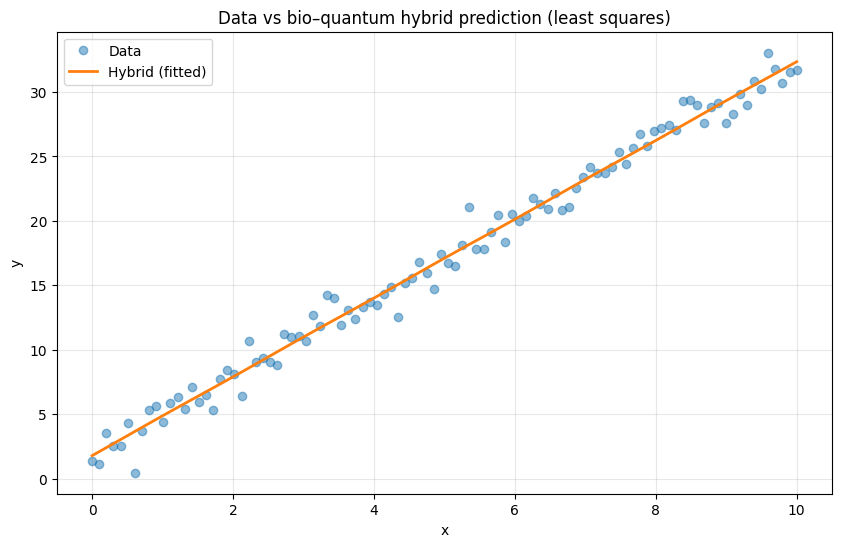

In [ ]:
# Data vs hybrid predictions at each sample (trained weights)
predicted_y_hybrid = b_hybrid + wqc_fit * q_feat + wboi_fit * bio_feat
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'o', label='Data', alpha=0.5)
plt.plot(x_data, predicted_y_hybrid, '-', label='Hybrid (fitted)', lw=2)
plt.title('Data vs bio–quantum hybrid prediction (least squares)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Additional experiment: Iris dataset

**Iris** (sklearn): regress **petal length** on **sepal length** (150 samples). The input feature is scaled to **[0, 1]** so RY rotations and the neuron dynamics stay well-behaved—the same four-model pipeline as the synthetic experiment above.

Iris — MSE by model (target: petal length):
  Classical (baseline): 0.7431
  Classical + quantum noise (q feature): 0.7351
  Classical + bio-inspired only: 0.7431
  Bio–quantum hybrid: 0.7283


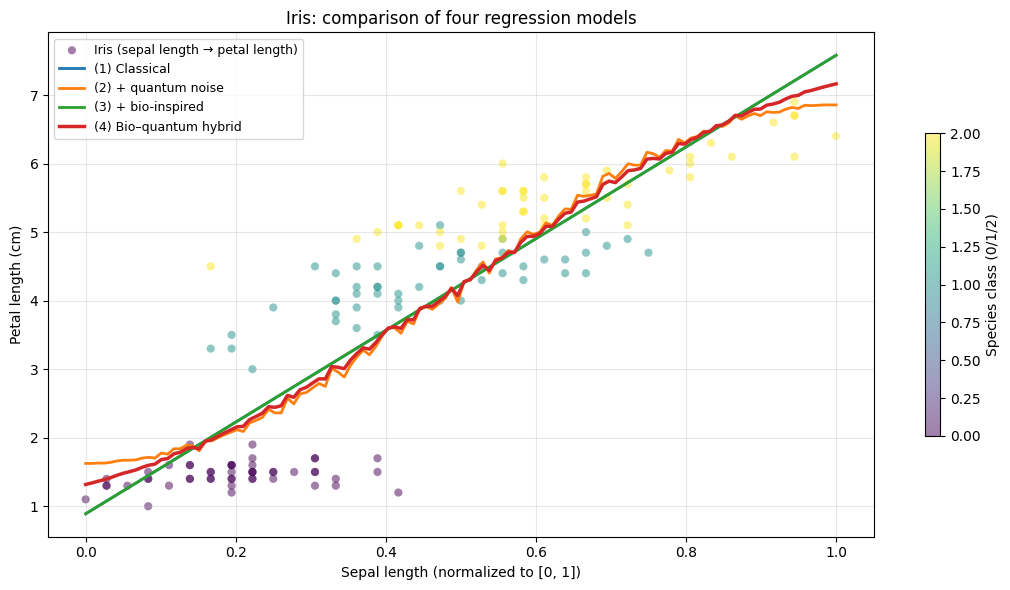

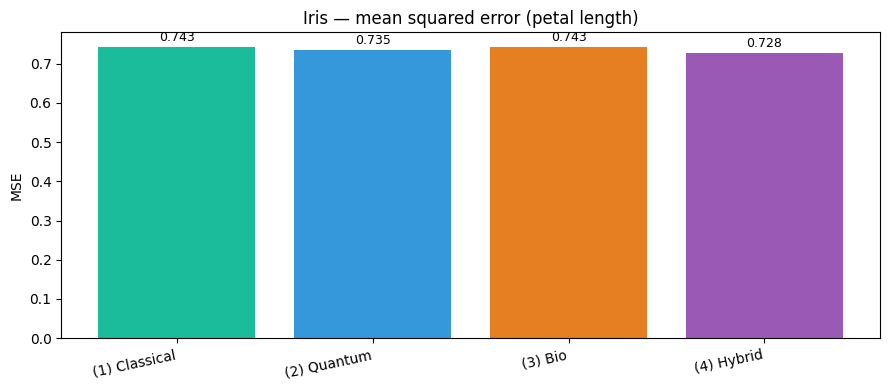

In [ ]:
from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

iris = load_iris()
# x: sepal length (cm), y: petal length (cm) — both continuous
x_raw = iris.data[:, 0].astype(float)
y_iris = iris.data[:, 2].astype(float)
# Scale x to [0, 1] for quantum / neuron encoding
xr_min, xr_max = x_raw.min(), x_raw.max()
x_iris = (x_raw - xr_min) / (xr_max - xr_min + 1e-12)

n_iris = len(x_iris)

# --- (1) Classical
X_c = np.column_stack([np.ones(n_iris), x_iris])
b_c, *_ = np.linalg.lstsq(X_c, y_iris, rcond=None)
y_p_c = X_c @ b_c

# --- (2) Quantum noise (q feature)
q_iris = np.array([float_to_qubit_prob(float(xv)) for xv in x_iris])
X_q = np.column_stack([np.ones(n_iris), q_iris])
b_q, *_ = np.linalg.lstsq(X_q, y_iris, rcond=None)
y_p_q = X_q @ b_q

# --- (3) Bio-inspired
bio_iris = np.array([simple_neuron_operator(float(xv)) for xv in x_iris])
X_b = np.column_stack([np.ones(n_iris), bio_iris])
b_b, *_ = np.linalg.lstsq(X_b, y_iris, rcond=None)
y_p_b = X_b @ b_b

# --- (4) Hybrid
X_h = np.column_stack([np.ones(n_iris), q_iris, bio_iris])
b_h, *_ = np.linalg.lstsq(X_h, y_iris, rcond=None)
y_p_h = X_h @ b_h

results_iris = {
    "Classical (baseline)": mean_squared_error(y_iris, y_p_c),
    "Classical + quantum noise (q feature)": mean_squared_error(y_iris, y_p_q),
    "Classical + bio-inspired only": mean_squared_error(y_iris, y_p_b),
    "Bio–quantum hybrid": mean_squared_error(y_iris, y_p_h),
}

print("Iris — MSE by model (target: petal length):")
for name, mse in results_iris.items():
    print(f"  {name}: {mse:.4f}")

xs_i = np.linspace(0.0, 1.0, 120)
q_line_i = np.array([float_to_qubit_prob(float(xv)) for xv in xs_i])
bio_line_i = np.array([simple_neuron_operator(float(xv)) for xv in xs_i])

y_l_c = b_c[0] + b_c[1] * xs_i
y_l_q = b_q[0] + b_q[1] * q_line_i
y_l_b = b_b[0] + b_b[1] * bio_line_i
y_l_h = b_h[0] + b_h[1] * q_line_i + b_h[2] * bio_line_i

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(x_iris, y_iris, alpha=0.5, label="Iris (sepal length → petal length)", s=35, edgecolors="none", c=iris.target, cmap="viridis")
ax.plot(xs_i, y_l_c, lw=2, label="(1) Classical")
ax.plot(xs_i, y_l_q, lw=2, label="(2) + quantum noise")
ax.plot(xs_i, y_l_b, lw=2, label="(3) + bio-inspired")
ax.plot(xs_i, y_l_h, lw=2.5, label="(4) Bio–quantum hybrid")
ax.set_xlabel("Sepal length (normalized to [0, 1])")
ax.set_ylabel("Petal length (cm)")
ax.set_title("Iris: comparison of four regression models")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
cbar = fig.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Species class (0/1/2)")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 4))
mses_i = list(results_iris.values())
colors = ["#1abc9c", "#3498db", "#e67e22", "#9b59b6"]
ax2.bar(range(4), mses_i, color=colors)
ax2.set_xticks(range(4))
ax2.set_xticklabels(["(1) Classical", "(2) Quantum", "(3) Bio", "(4) Hybrid"], rotation=12, ha="right")
ax2.set_ylabel("MSE")
ax2.set_title("Iris — mean squared error (petal length)")
m0 = max(mses_i) if mses_i else 1.0
for i, v in enumerate(mses_i):
    ax2.text(i, v + 0.02 * m0, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()